In [35]:
import matplotlib.pyplot as plt
import numpy as np
import os

plt.style.use('../my_style.mplstyle')

r = 0.59
d = 0.025
l = 0.010
r_a = np.sqrt(2 * r * d / (1 + d/r)**2)
r_dna = np.sqrt((d+2*l)*(2*r+2*l))/(r*(1+(2*l+d/2)/r))

f = 1.13e-2
epsilon = np.sqrt(np.exp(1)/2) * r_a * f 

k_cargo = 2.26e-2
v = 0.5
tau = r/v

Coefficient: 0.9999999999999999


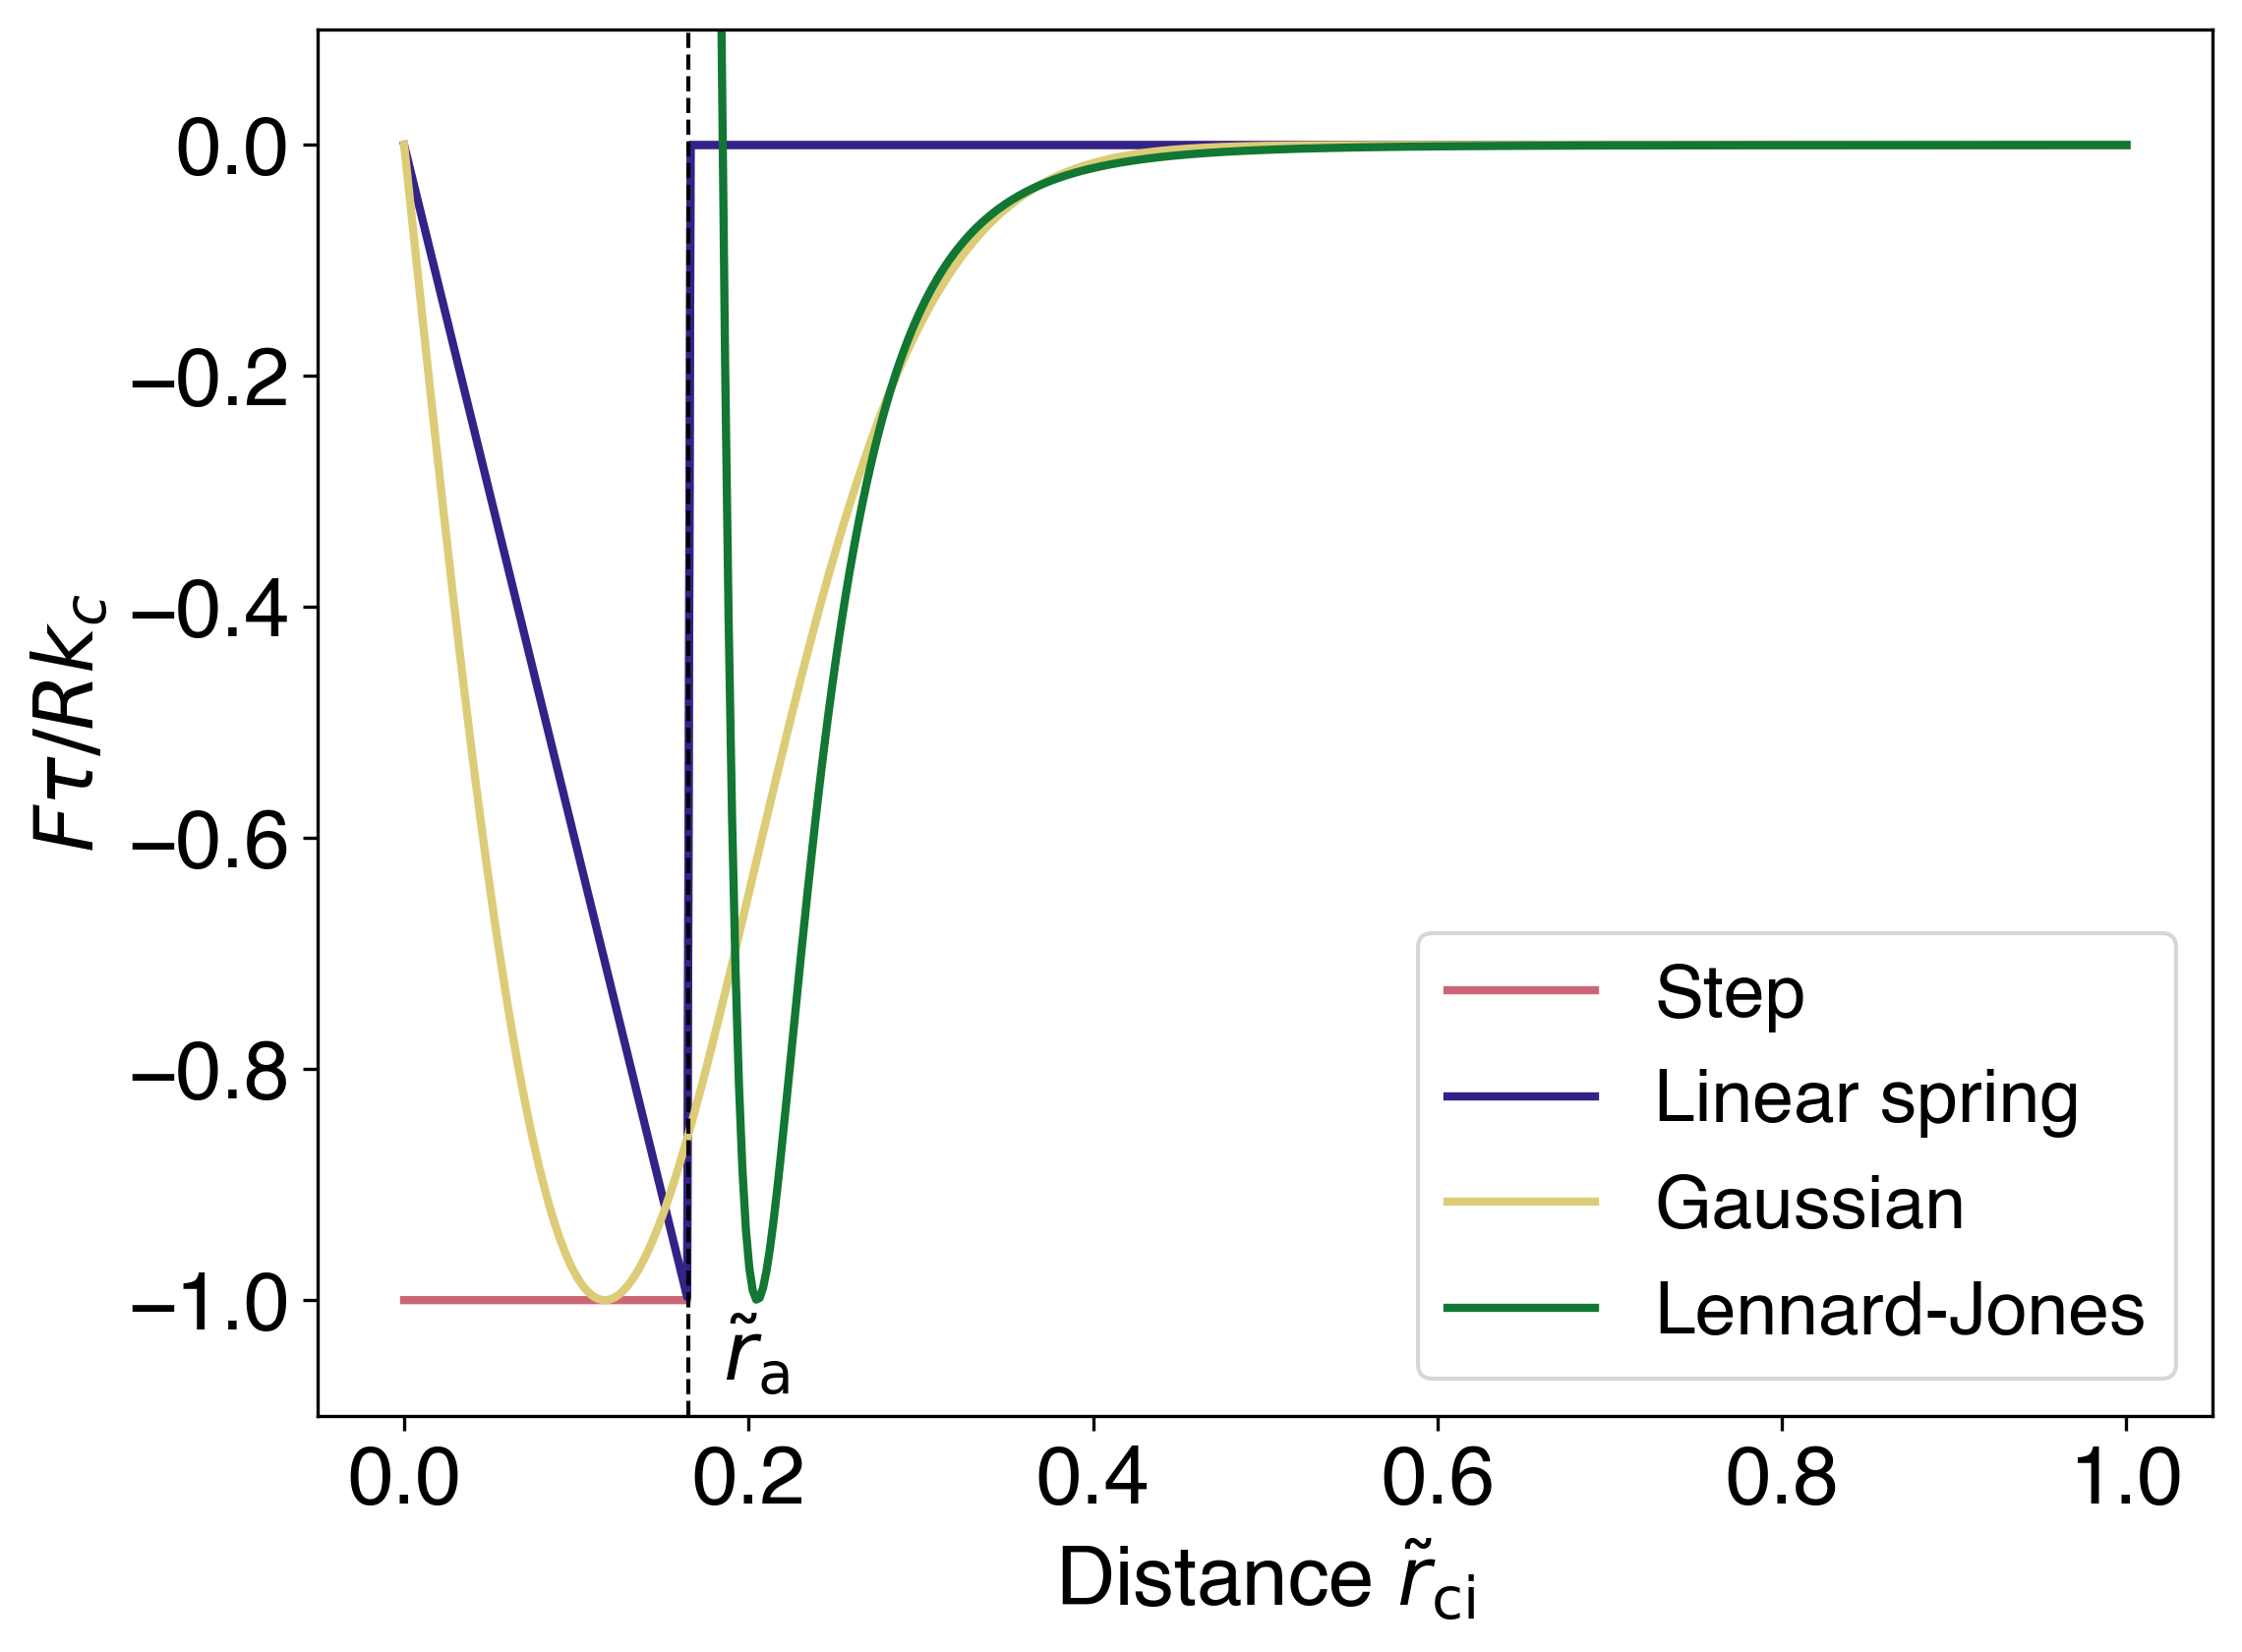

In [40]:
def dna_force_gaussian(epsilon, r, r_a):
    return -2 * epsilon * r * np.exp(-(r**2)/(r_a**2)) / (r_a**2)

def dna_force(f, r, r_a):
    if r < r_a:
        return -f
    else:
        return 0.0

def dna_force_spring(f, r, r_a, r_dna):
    if r < r_a:
        return -f
    elif r_a <= r < r_dna:
        return -f * (r_dna - r) / (r_dna - r_a)
    else:
        return 0.0
    
def spring_force(f, r, r_a):
    if r < r_a:
        return -f * r/r_a
    else:
        return 0

def Lennard_force(epsilon, r, sigma):
    return -4 * epsilon * ((-12 * (sigma**12) / (r**13)) + (6 * (sigma**6) / (r**7)))



LJ_e = (13/144) * ((26/7)**(7/6)) * r_a * f

coefficient = tau / (k_cargo * r)

print("Coefficient:", f*coefficient)

distances = np.linspace(0, 1.0, 500)

fig, ax = plt.subplots()

ax.plot(distances, [dna_force(f*coefficient, r, r_a) for r in distances], label='Step')
#ax.plot(distances, [dna_force_spring(f*coefficient, r, r_a, r_dna) for r in distances], label='DNA spring')
ax.plot(distances, [spring_force(f*coefficient, r, r_a) for r in distances], label='Linear spring')
ax.plot(distances, [dna_force_gaussian(epsilon*coefficient, r, r_a) for r in distances], label='Gaussian')

LJ_distances = distances[distances > r_a*0.9]

ax.plot(LJ_distances, [Lennard_force(LJ_e*coefficient, r, r_a) for r in LJ_distances], label='Lennard-Jones')

ax.axvline(r_a, color='black', lw=1, ls='--')
#ax.axvline(r_dna, color='black', lw=1, ls='--')

ax.text(r_a + 0.02, -1.07*f*coefficient, '$\\tilde{r}_\mathrm{a}$')
#ax.text(r_dna + 0.02, -f*coefficient, '$\hat{r}_\mathrm{dna}$')

ax.set_xlabel('Distance $\\tilde{r}_\mathrm{ci}$')
ax.set_ylabel('$F\\tau/R k_c$')
ax.set_ylim(-1.1*f*coefficient, 0.1)
ax.legend()
plt.show()

fig.savefig('../figures/dna_force_comparison.png', bbox_inches='tight')
fig.savefig('../figures/dna_force_comparison.pdf', bbox_inches='tight')

Coefficient: 1.3139999999999998


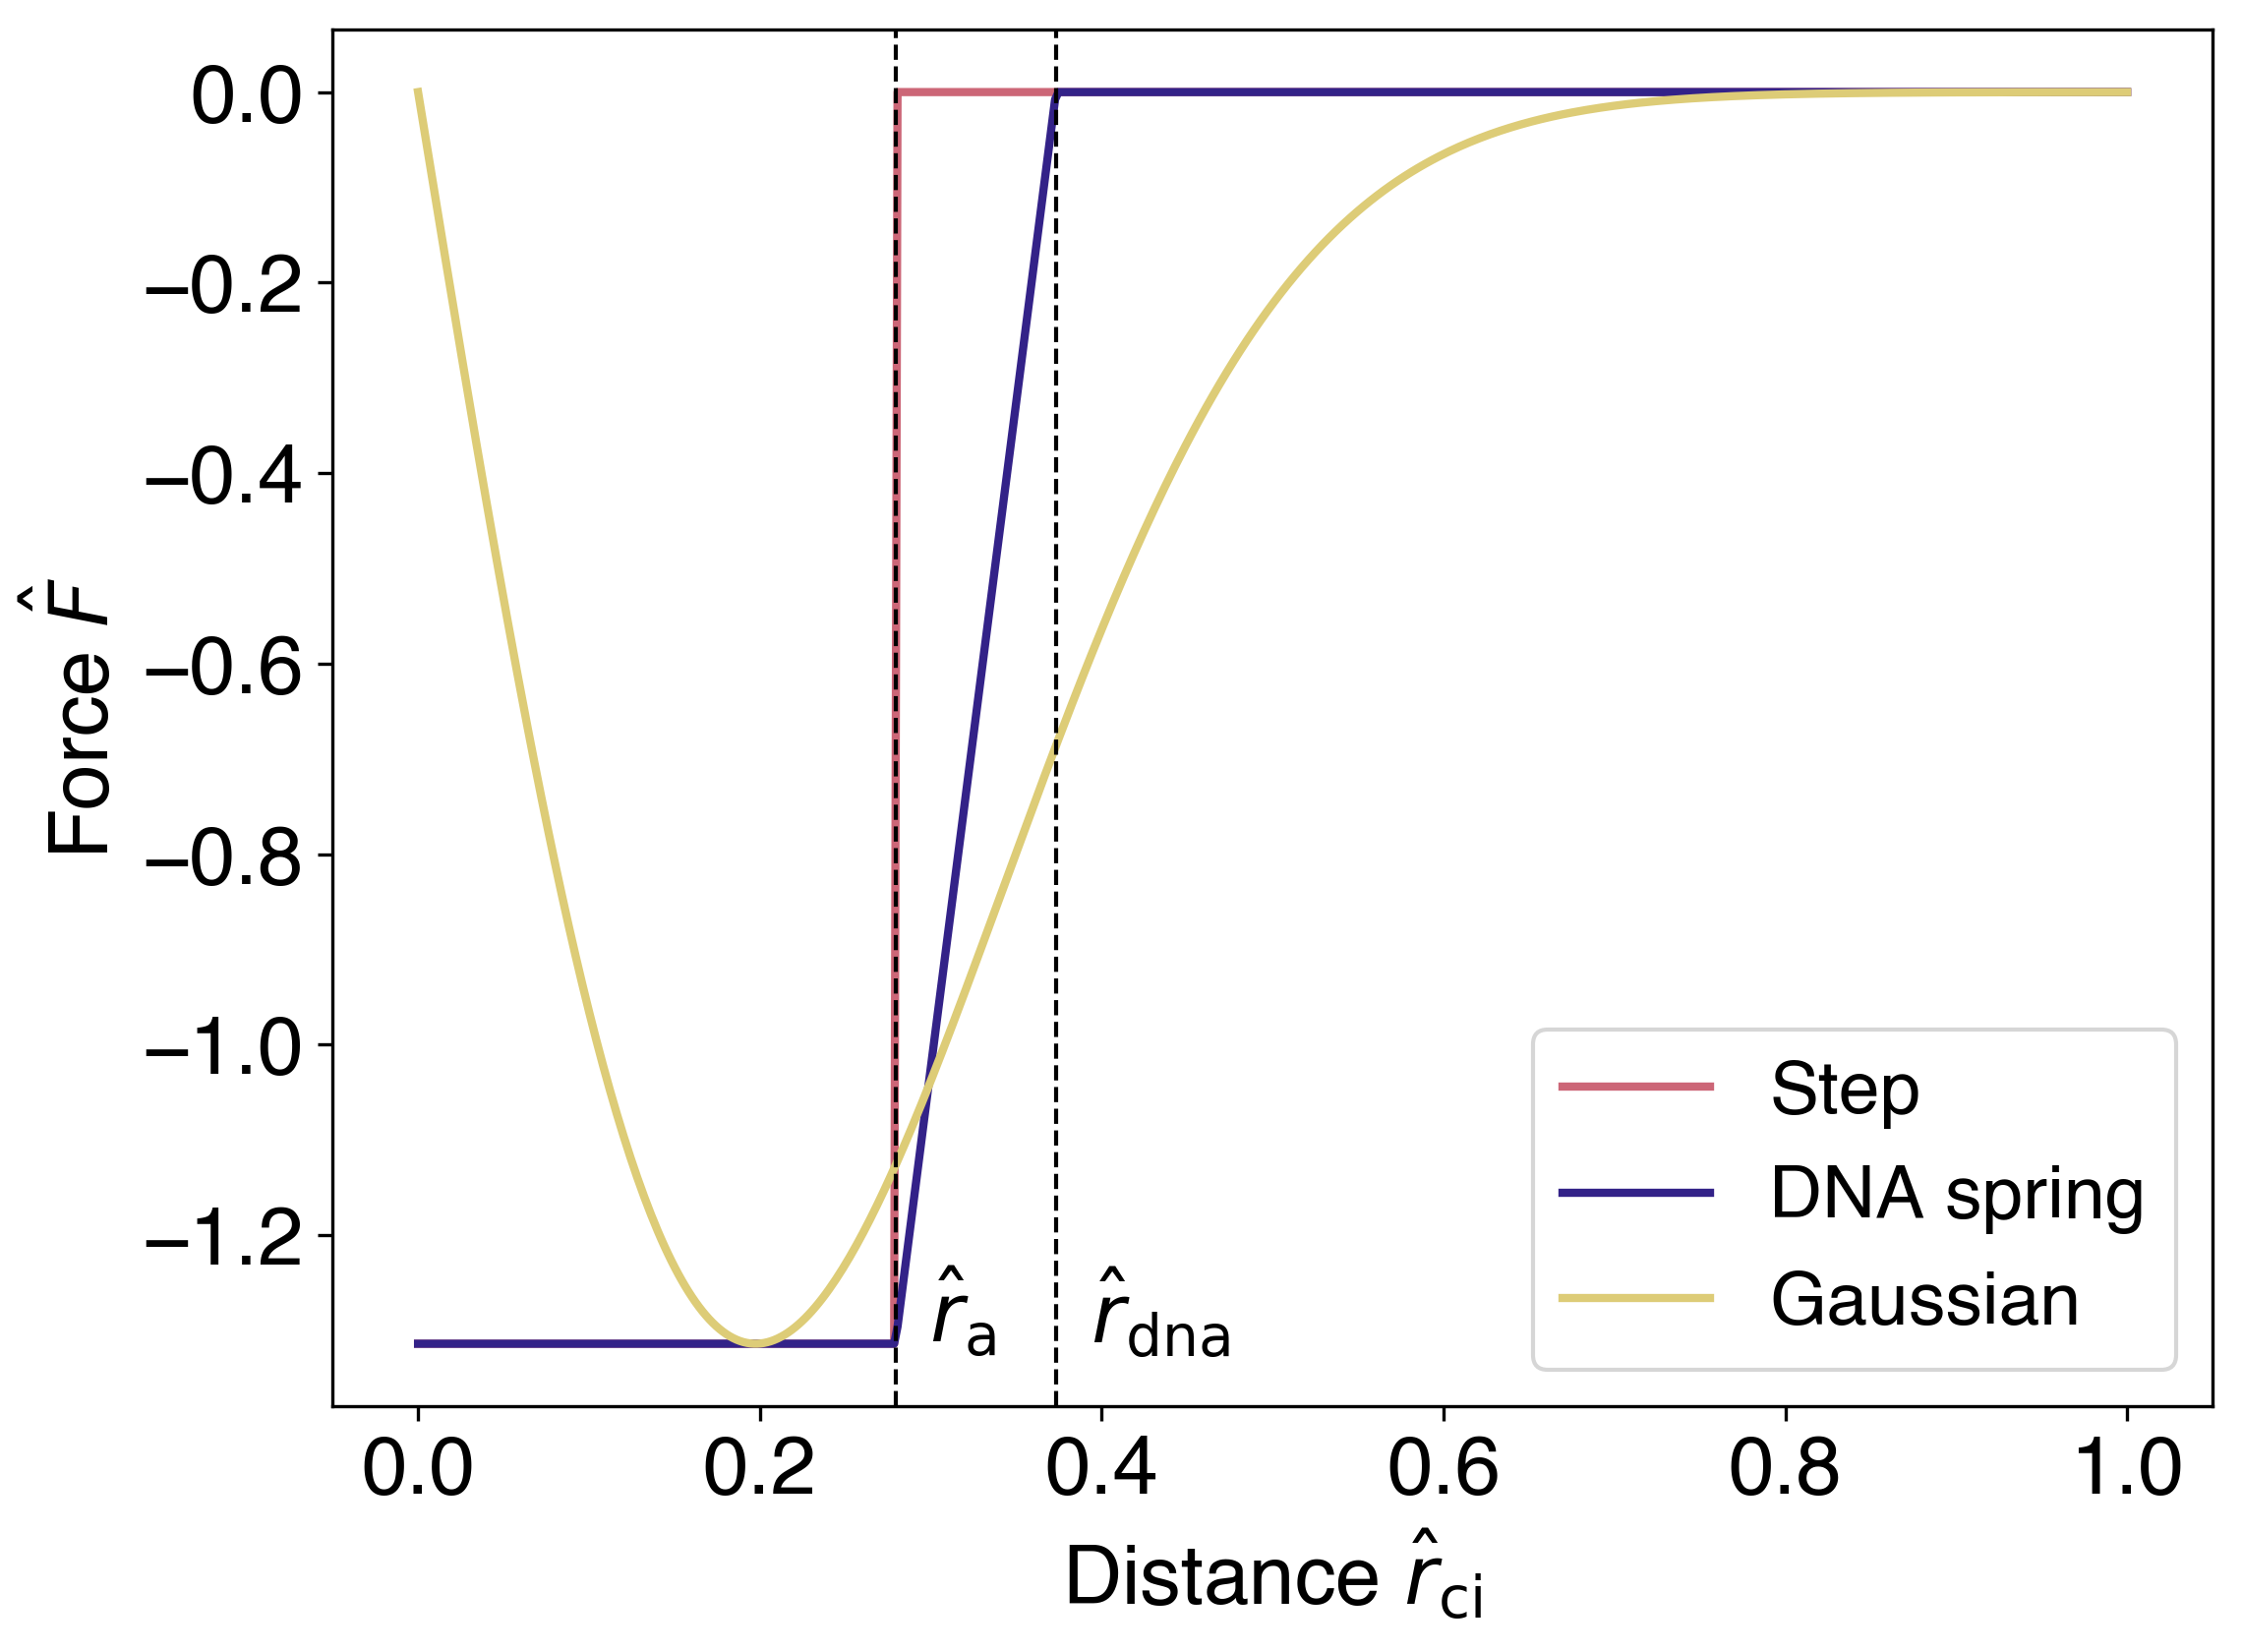

In [54]:
k_cargo = 1.0e-9
v = 0.5
tau = r/v

coefficient = tau / (k_cargo * r)

print("Coefficient:", f*coefficient)

fig, ax = plt.subplots()

ax.plot(distances, [dna_force(f*coefficient, r, r_a) for r in distances], label='Step')
ax.plot(distances, [dna_force_spring(f*coefficient, r, r_a, r_dna) for r in distances], label='DNA spring')
ax.plot(distances, [dna_force_gaussian(epsilon*coefficient, r, r_a) for r in distances], label='Gaussian')

ax.axvline(r_a, color='black', lw=1, ls='--')
ax.axvline(r_dna, color='black', lw=1, ls='--')

ax.text(r_a + 0.02, -f*coefficient, '$\hat{r}_\mathrm{a}$')
ax.text(r_dna + 0.02, -f*coefficient, '$\hat{r}_\mathrm{dna}$')

ax.set_xlabel('Distance $\hat{r}_\mathrm{ci}$')
ax.set_ylabel('Force $\hat{F}$')
ax.legend()
plt.show()

fig.savefig('../figures/dna_force_comparison.png', bbox_inches='tight')
fig.savefig('../figures/dna_force_comparison.pdf', bbox_inches='tight')

In [ ]:
import numpy as np
import glob

def orderparameter(orientation):
    vec = np.array([np.cos(orientation), np.sin(orientation)])
    cos = vec[0, :, :]
    sin = vec[1, :, :]

    cosS = np.sum(vec[0, :, :], axis=1)
    sinS = np.sum(vec[1, :, :], axis=1)

    mean = np.arctan2(sinS, cosS)

    cosdtheta = cos * np.cos(mean)[:, None] + sin * np.sin(mean)[:, None]
    cos2_Em = np.mean(cosdtheta**2, axis=1)
    S = 2*(cos2_Em - 1/2)

    return S

folder = "../data/MT/P0.5_A0.0"
files = glob.glob(f"{folder}/seed*")

S_lists = []

for file in files:
    orientation = np.load(f"{file}/orientations_history.npy")
    S = orderparameter(orientation)
    S_lists.append(S)
S_array = np.array(S_lists)

(-1.0, 1.0)

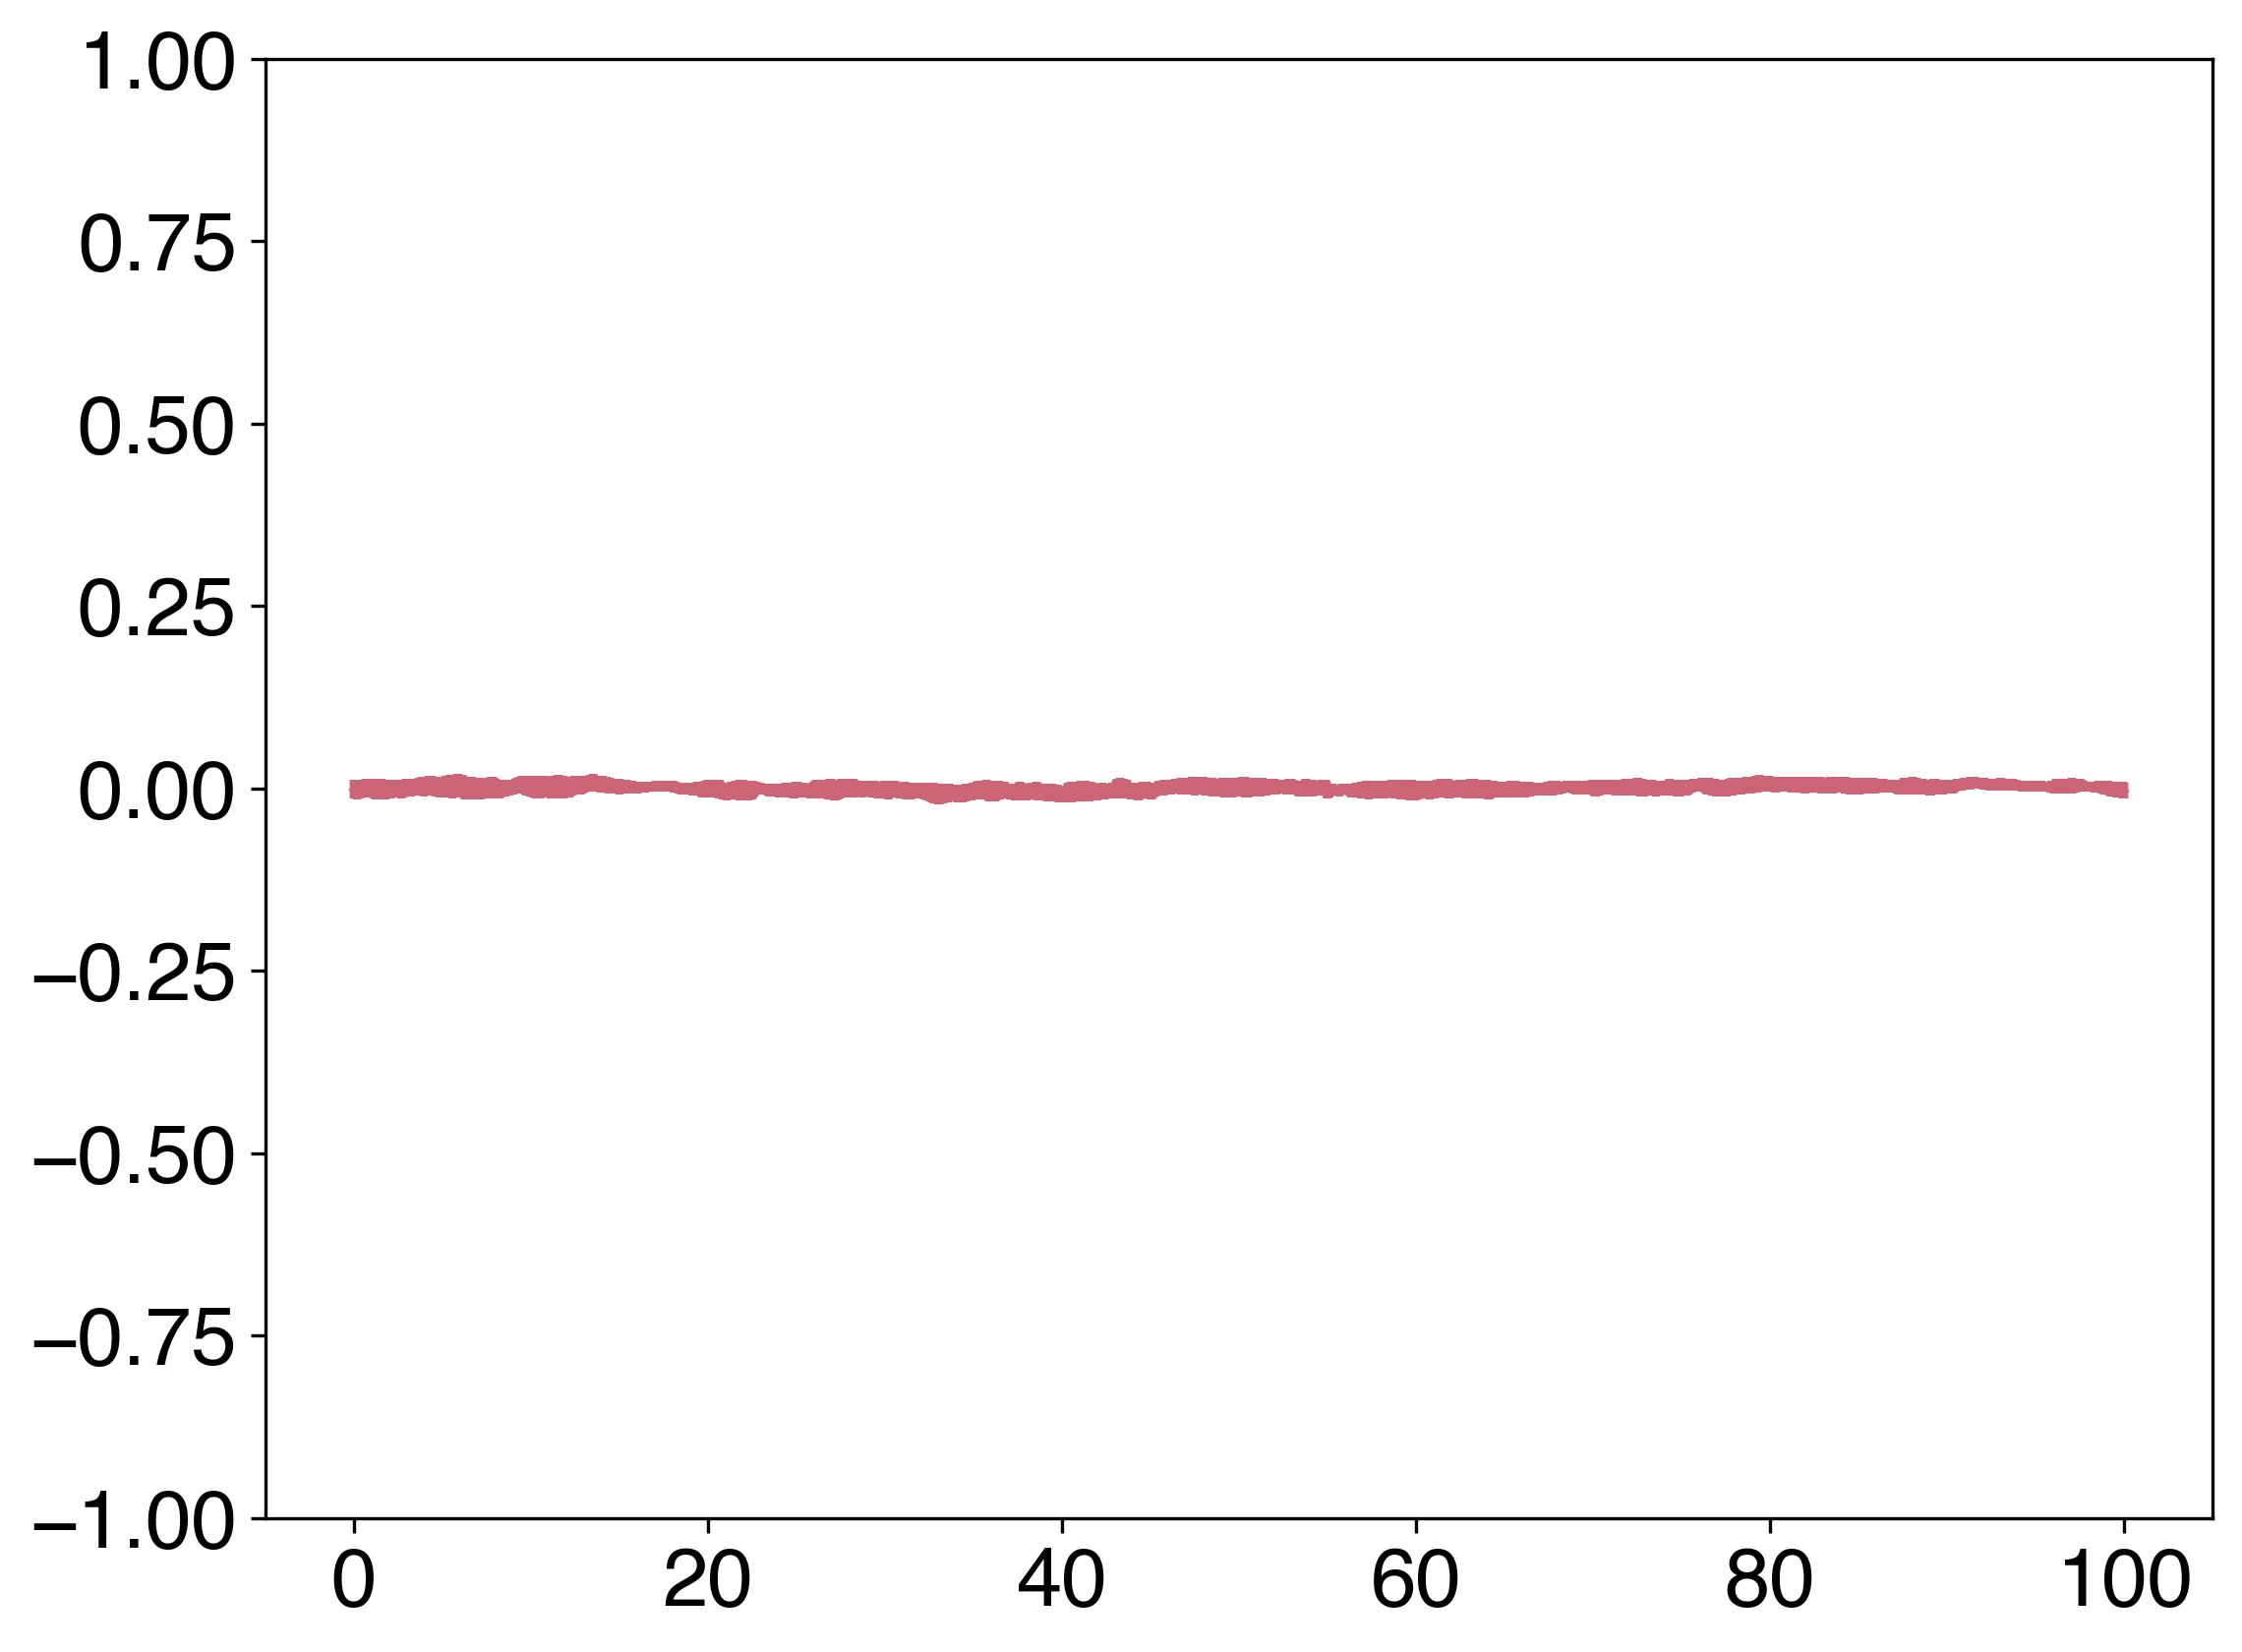

In [150]:
import matplotlib.pyplot as plt

S_em = np.mean(S_array, axis = 0)
S_std = np.std(S_array, axis = 0)

fig, ax = plt.subplots()

ax.errorbar(np.arange(0, 10000)*0.01, S_em, S_std)

ax.set_ylim((-1,1))